In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from functions import Functions

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [4]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [5]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [6]:
extent = [138, 150,-68,-64]
extent_tt = [116,122,-67.5,-63]
extent_vc = [105,111,-67,-64]
extent_pb = [67,82,-70,-66]

mertz = Region('Mertz',extent)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [7]:
# set up lines of constant density

def sig0range(tlims,slims):
    sig0_n = 100
    temprange = np.linspace(tlims[0],tlims[1],sig0_n)
    psalrange = np.linspace(slims[0],slims[1],sig0_n)

    sig0range = np.zeros((sig0_n,sig0_n))
    for i,t in enumerate(temprange):
        for j,s in enumerate(psalrange):
            sig0range[i,j]=gsw.sigma0(gsw.conversions.SA_from_SP(s,0,145,-67),gsw.CT_from_t(s,t,0))
    return temprange,psalrange,sig0range


In [8]:
dscli = xr.open_dataset(fname_zhou)
dscli = dscli.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})
dscli = fns.crop_to_extent(dscli,extent)


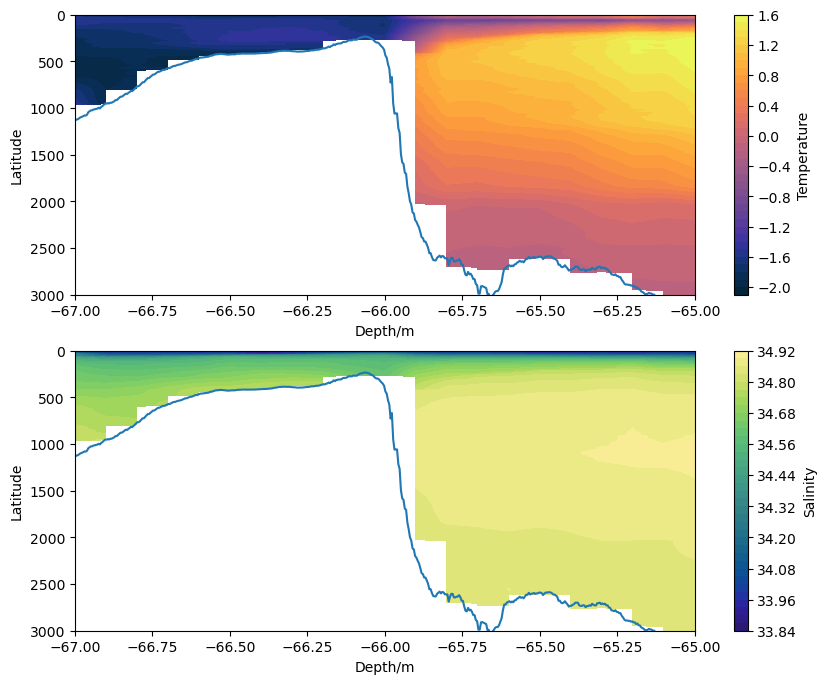

In [9]:
clim_139E = dscli.where(dscli.longitude==145,drop=True).squeeze()

fig, axs = plt.subplots(2,1,figsize=(10,8))
ax=axs[0]
im=ax.contourf(clim_139E.latitude,clim_139E.pressure,clim_139E.ct,cmap=cmocean.cm.thermal,levels=40)
ax.plot(elevation.latitude,-elevation.sel(longitude=145,method='nearest'))
ax.set_ylim([0,3000])
ax.set_xlim([-67,-65])
ax.set_xlabel('Depth/m')
ax.set_ylabel('Latitude')
ax.invert_yaxis()

cbar = plt.colorbar(im)
cbar.set_label('Temperature')
ax=axs[1]
im=ax.contourf(clim_139E.latitude,clim_139E.pressure,clim_139E.sa,cmap=cmocean.cm.haline,levels=40)
ax.plot(elevation.latitude,-elevation.sel(longitude=145,method='nearest'))
ax.set_ylim([0,3000])
ax.set_xlim([-67,-65])
ax.set_xlabel('Depth/m')
ax.set_ylabel('Latitude')
ax.invert_yaxis()

cbar = plt.colorbar(im)
cbar.set_label('Salinity')


In [10]:
ds = pickle.load(open('c3data.pkl','rb'))

In [10]:
ds = xr.open_dataset(fname_spira).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [11]:
meop=MEOP(extent=extent)
meop.load_profiles_for_spira()

100%|██████████| 84/84 [02:02<00:00,  1.46s/it]
/nfs/b0133/eejco/chapter_2/load_meop.py:129: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  self.ds = xr.Dataset.from_dict({


In [12]:
# get new seals data (recorded after Spira cutoff date)
seals = meop.ds.sortby('time').sel(time=slice(ds.time[-1],pd.Timestamp(2026,1,1)))

# filter silly values
seals = seals.where(~((seals.psal < 30) | (seals.psal > 36)))

In [13]:
seals25 = seals.where(seals.pres < 25,drop=True)
seals300 = seals.where(seals.pres < 300,drop=True)

In [14]:
# make sure there is a value above 25dbar
keep = []
for t in seals.time:
    tmp25 = seals25.sel(time=t)
    tmp300 = seals300.sel(time=t)
    boo25 = np.any(~np.isnan(seals25.temp) & ~np.isnan(seals25.psal))
    boo300 = (~np.isnan(seals300.temp) & ~np.isnan(seals300.psal)).sum() > 5
    keep.append(boo25.item() & boo300.item())
print('kept {0} of {1} profiles'.format(np.array(keep).sum(),len(seals.time)))

kept 1698 of 1698 profiles


In [15]:
ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])

In [16]:
ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])
ds['month'] = ds.time.dt.month
ds['year'] = ds.time.dt.year
ds['asal'] = gsw.conversions.SA_from_SP(ds.psal,ds.pres,145,ds.lat)
ds['ctemp'] = gsw.conversions.CT_from_t(ds.asal,ds.temp,ds.pres)
ds['rho'] = gsw.density.rho(ds.asal,ds.ctemp,ds.pres)
ds['sigma0'] = gsw.density.sigma0(ds.asal,ds.ctemp)
ds['month'] = ds.time.dt.month

/tmp/ipykernel_25290/4054770901.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])


In [21]:
with open('c3data.pkl', 'wb') as file:
    pickle.dump(ds, file)

In [11]:
ds_shelf = ds.where(ds.elevation > -1000,drop=True)

In [12]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons

seasons = get_seasons(ds_shelf)
seasons_all = get_seasons(ds)



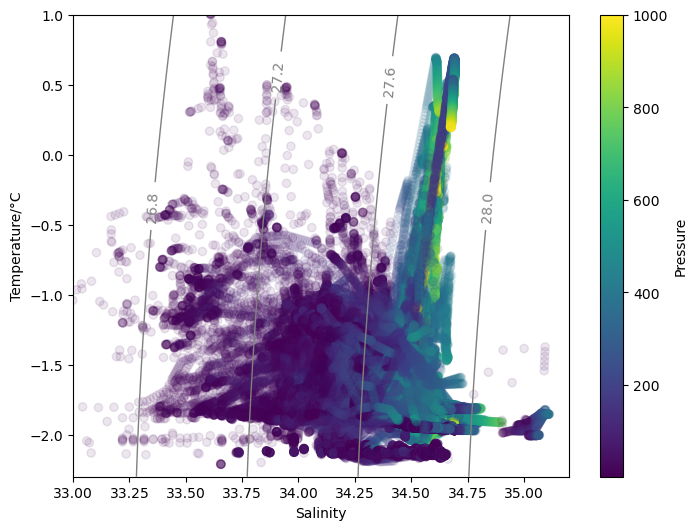

In [13]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
# shapes=['o','s','*','D']
# for s,c in zip(seasons,shapes):
im=ax.scatter(ds_shelf.psal,ds_shelf.temp,alpha=0.05,c=ds_shelf.pres.broadcast_like(ds_shelf.time))

tlim=[-2.3,1]
slim=[33,35.2]
temprange,psalrange,sig0range_ = sig0range(tlim,slim)
cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
ax.set_xlim(slim)
ax.set_ylim(tlim)
ax.set_ylabel('Temperature/°C')
ax.set_xlabel('Salinity')

im.set_alpha(1)          # make colorbar opaque
bar=plt.colorbar(im)
im.set_alpha(0.1)

bar.set_label('Pressure')

In [ ]:
#find seals which travel a decent (>1 degree) meridional distance
mdlmax = ds.reset_coords().groupby('profile_code').max().lat
mdlmin = ds.reset_coords().groupby('profile_code').min().lat
mdemax = ds.reset_coords().groupby('profile_code').max().elevation
mdemin= ds.reset_coords().groupby('profile_code').min().elevation

longg = mdlmax.time.where(((mdlmax - mdlmin) > 0.6) & ((mdemax - mdemin) > 800), drop=True)

In [15]:
longg

<xarray.DataArray 'profile_code' (profile_code: 2)> Size: 16B
array(['ft33-791-22', 'wd20-546-19'], dtype=object)
Coordinates:
  * profile_code  (profile_code) object 16B 'ft33-791-22' 'wd20-546-19'

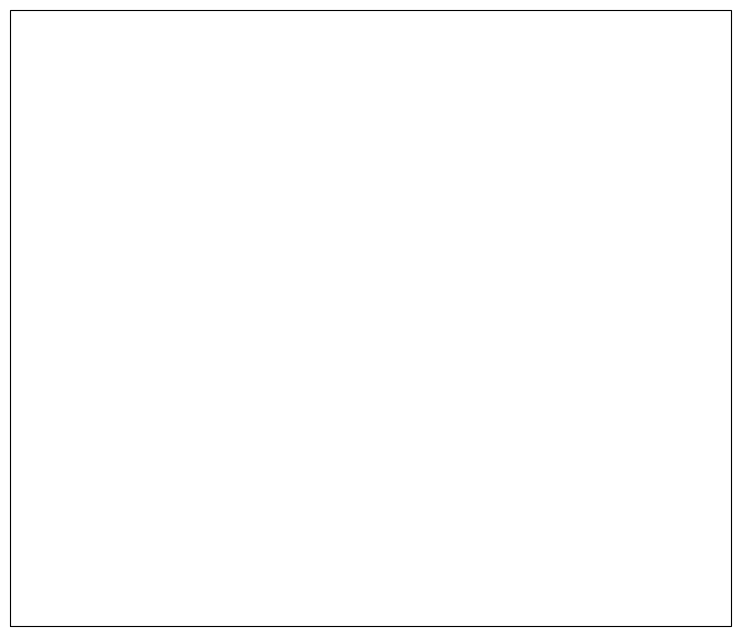

In [16]:
pc = longg[0]
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.Mercator()})
# pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
# for platform in longg:
#     dff = ds.where(ds.profile_code == platform,drop=True)
#     ax.scatter(dff.lon,dff.lat,transform=ccrs.PlateCarree(),label=platform.item())
# ax.legend()

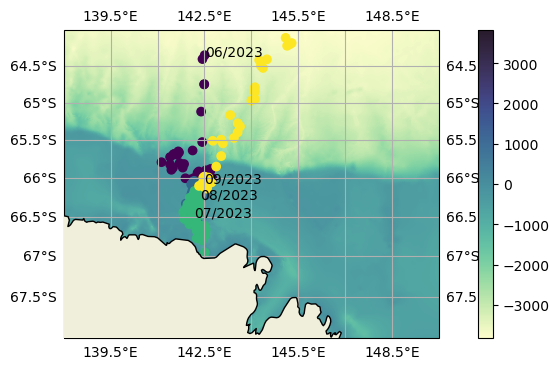

In [40]:
pc = longg[0].item() #'ct84-744-12'#'ct64-M052-09'#'ft33-791-22'
dspc = ds.where(ds.profile_code == pc,drop=True)
fig,ax=plt.subplots(figsize=(10,4),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep)
ax.scatter(dspc.lon,dspc.lat,c=dspc.month.sel(pres=0),transform=ccrs.PlateCarree(),label=pc)
for m in np.unique(dspc.month):
    eg = dspc.where(dspc.month==m,drop=True).isel(time=0)
    tstr = eg.time.dt.strftime("%m/%Y").item()
    ax.text(eg.lon,eg.lat,tstr,transform=ccrs.PlateCarree())
plt.colorbar(im)

In [44]:
dsm = dspc.where((dspc.month == 9) | (dspc.month == 8),drop=True)
dsml = dsm.swap_dims({'time':'lat'}).sortby('lat')
keep = ~(np.isnan(dsml.sigma0))
x=xr.broadcast(dsml.lat,dsml.pres)[0].where(keep,drop=True).to_numpy().flatten()
y=xr.broadcast(dsml.lat,dsml.pres)[1].where(keep,drop=True).to_numpy().flatten()

Text(0.5, 1.0, 'potential density')

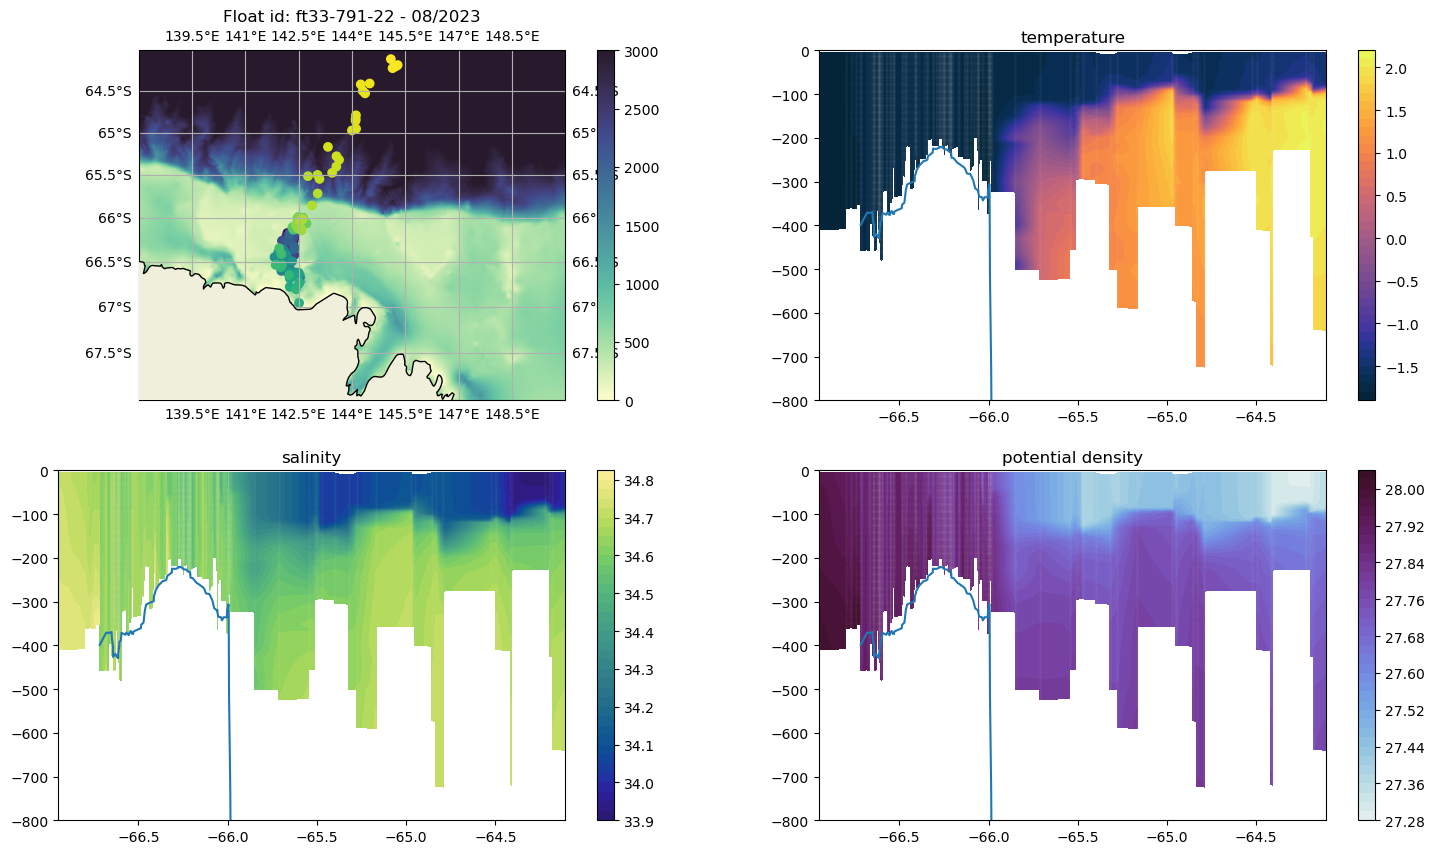

In [46]:

fig = plt.figure(figsize=(18,10))
gs = fig.add_gridspec(2,2)

et = elevation.interp({'latitude':dsml.lat,'longitude':dsml.lon}).rolling({'lat':10},center=True).mean()
minz = -800
levels = 40

ax = fig.add_subplot(gs[0, 0],projection=ccrs.Mercator())
im=pfns.sp(ax,-elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3,vmin=0,vmax=3000)
ax.scatter(dsm.lon,dsm.lat,c=dsm.time,transform=ccrs.PlateCarree(),label=pc)
plt.colorbar(im)
ax.set_title('Float id: ' + pc + ' - ' + dsm.time[0].dt.strftime("%m/%Y").item())

ax = fig.add_subplot(gs[0, 1])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.temp.T,cmap=cmocean.cm.thermal,levels=levels)#np.linspace(-1.8,0,levels),vmin=-1.8,vmax=0)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.001)
ax.set_title('temperature')

ax = fig.add_subplot(gs[1, 0])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.psal.T,cmap=cmocean.cm.haline,levels=levels)#,vmin=34.2,vmax=34.7)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.001)
ax.set_title('salinity')

ax = fig.add_subplot(gs[1, 1])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.sigma0.T,cmap=cmocean.cm.dense,levels=levels)#,vmin=27.5,vmax=28)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.001)
ax.set_title('potential density')

KeyError: "No variable named 'sigma0'. Variables on the dataset include ['temp', 'psal', 'dsource', 'mld', 'asal', ..., 'time', 'pres', 'lon', 'lat', 'n_prof']"

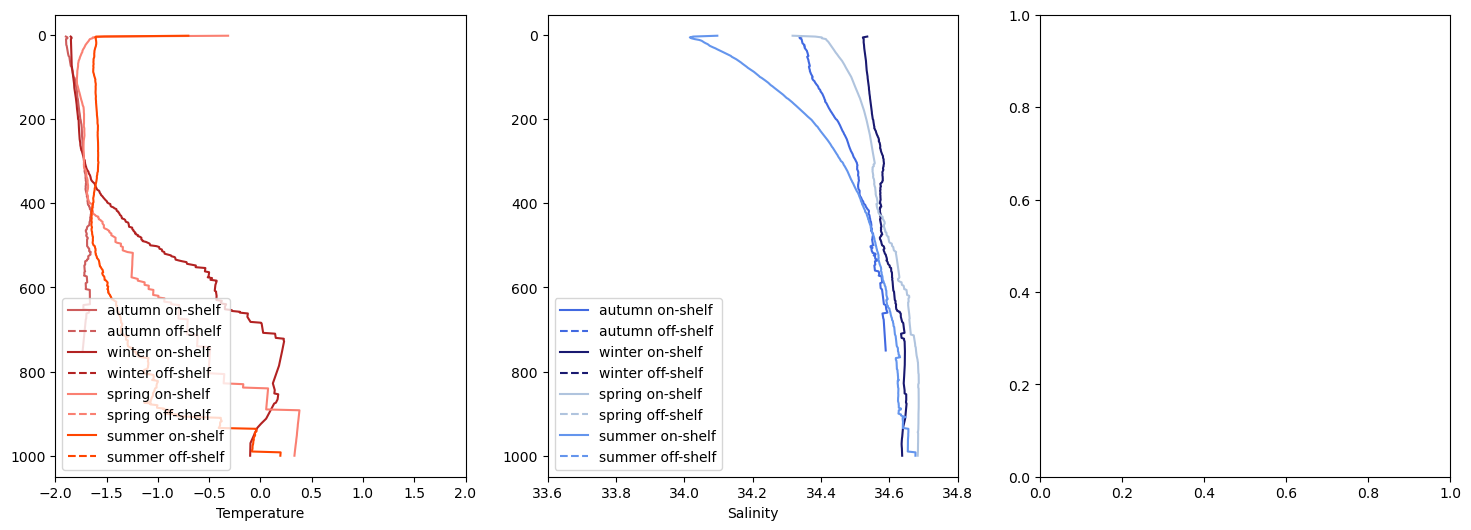

In [21]:
fig, ax = plt.subplots(1,3,figsize=(18,6))
def plot_var(ax,var,title,c,ylim):
    for i,s in enumerate(seasons):
        #get onslope profile
        data=seasons[s].where(seasons[s].elevation > -1000,drop=True)[var].mean('time')
        ax.plot(data,data.pres,'-',c=c[i],label=s + ' on-shelf')
        #get offslope profile
        data=seasons[s].where(seasons[s].elevation < -1000,drop=True)[var].mean('time')
        ax.plot(data,data.pres,'--',c=c[i],label=s+' off-shelf')
    ax.invert_yaxis()
    ax.set_xlim(ylim)
    ax.set_xlabel(title)
    ax.legend(loc='lower left')



plot_var(ax[0],'temp','Temperature',['indianred','firebrick','salmon','orangered'],[-2,2])
plot_var(ax[1],'psal','Salinity',['royalblue','midnightblue','lightsteelblue','cornflowerblue'],[33.6,34.8])
plot_var(ax[2],'sigma0','Density',['mediumvioletred','darkmagenta','plum','violet'],[1027,1027.9])



In [ ]:
# some example sections